# 다음영화 리뷰의 키워드 분석

1. 데이터 준비 (로딩)
2. 텍스트 전처리 (토큰화, 불용어 제거)
3. 빈도수 분석 (Counter)

* 시각화 1 : 수평 막대그래프
* 시각화 2 : 워드클라우드

In [1]:
# 데이터 준비 (로딩)
data_path = './data/daum_movie_review.csv'
input_filename = 'daum_movie_review.csv'

import pandas as pd
movie_df = pd.read_csv(data_path)
# movie_df.head()
review_list = list(movie_df.review)
# review_list[:10]

In [2]:
# 텍스트 전처리
from konlpy.tag import Okt
tagger = Okt()

pos_list = []
for i in review_list:
    pos_list.extend(tagger.pos(i))
# pos_list[:100]

my_tags = ['Noun', 'Verb', 'Adjective']
my_tokens = [word for word, tag in pos_list if tag in my_tags]
# my_tokens[:100]

my_stopwords = ['듯', '걸', '더', '한', '이', '할', '나', '수', '줄', '즉', '내', '틈', '것', '적', '영화', '정말', '하는', '점', '그', '입니다', '그냥', '좀']
my_new_tokens = [token for token in my_tokens if token not in my_stopwords]
# my_new_tokens[:100]

In [3]:
# 빈도수 분석
from collections import Counter
const_counter = Counter(my_new_tokens)

# len(const_counter)

# print(list(const_counter.items())[:20])
# print(const_counter.most_common(20))
most_freq_list = const_counter.most_common(20)

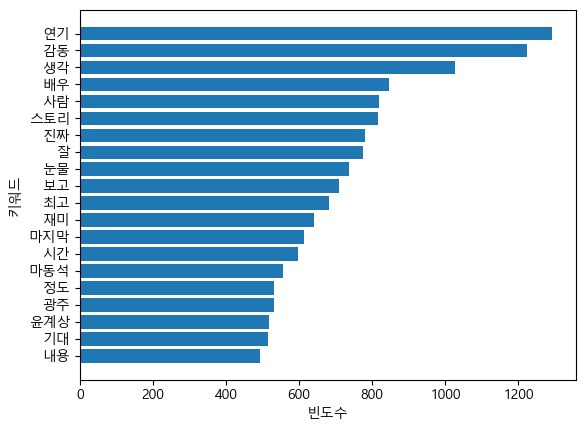

In [4]:
# 수평 막대그래프 시각화
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

x_list = [word for word, count in most_freq_list]
y_list = [count for word, count in most_freq_list]

plt.xlabel('빈도수')
plt.ylabel('키워드')

plt.barh(x_list[::-1], y_list[::-1])
# plt.show()
filename = './result/' + input_filename.replace('.csv', '_graph.jpg')
plt.savefig(filename)

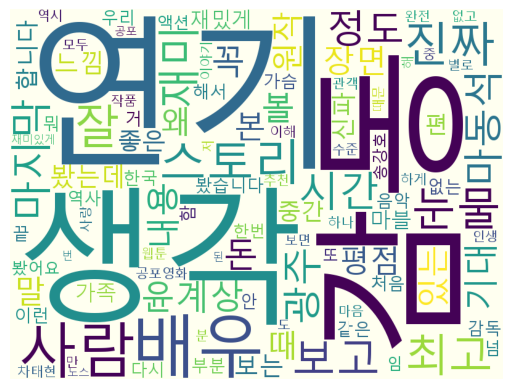

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

font_path = "c:/Windows/fonts/malgun.ttf"

const_wc = WordCloud(
    font_path = font_path,
    width = 800,
    height = 600,
    max_words = 100,
    background_color = 'ivory'
)

const_wc = const_wc.generate_from_frequencies(const_counter)

plt.imshow(const_wc)
plt.axis('off')
# plt.show()
result_filename = './result/' + input_filename.replace('.csv', '_wordcloud.jpg')
const_wc.to_file(result_filename)